# Phase 2 · A0 baseline: reproduced results

This notebook shows the results of our reproduction of Marques et al. (2022). The training itself runs in [`Phase2_Baseline_Reproduction_Marques2022.ipynb`](Phase2_Baseline_Reproduction_Marques2022.ipynb) on Kaggle (2× Tesla T4, 3 of 10 folds, about 21 min per fold). Its output files are saved in `results/A0_baseline/`, and this notebook loads them.

It needs only `pandas` and Jupyter (no GPU), so anyone can re-run it.

In [1]:
import json
import pandas as pd
from IPython.display import Image, display

R = "../results/A0_baseline"
s = json.load(open(f"{R}/A0_summary.json"))
print(f"Images: {s['n_images']:,}  ·  slides: {s['n_slides']}  ·  folds run: {s['folds_run']} of {s['config']['N_FOLDS']}")
print("Config:", {k: s['config'][k] for k in ['IMG_SIZE', 'BATCH_SIZE', 'EPOCHS', 'LR', 'MIN_LR', 'PLATEAU_PATIENCE', 'EARLY_STOP_PATIENCE', 'DROPOUT']})

Images: 27,558  ·  slides: 200  ·  folds run: 3 of 10
Config: {'IMG_SIZE': 224, 'BATCH_SIZE': 64, 'EPOCHS': 15, 'LR': 0.0001, 'MIN_LR': 1e-06, 'PLATEAU_PATIENCE': 6, 'EARLY_STOP_PATIENCE': 5, 'DROPOUT': 0.2}


## 1 · Each fold on its own validation split

In [2]:
folds = pd.read_csv(f"{R}/A0_baseline_per_fold_val.csv")
cols = ["accuracy", "precision", "recall", "specificity", "f1", "auc", "mcc"]
display(folds[["fold", "epochs", "minutes"] + cols].round(2))
display(pd.DataFrame({"mean": folds[cols].mean(), "sd": folds[cols].std(ddof=1)}).T.round(2))

,fold,epochs,minutes,accuracy,precision,recall,specificity,f1,auc,mcc
0,1,9,20.7,96.57,98.25,94.84,98.31,96.51,99.57,93.20
1,2,10,21.9,98.02,98.14,97.90,98.15,98.02,99.77,96.05
2,3,10,21.7,97.54,97.89,97.18,97.90,97.53,99.70,95.08


,accuracy,precision,recall,specificity,f1,auc,mcc
mean,97.38,98.09,96.64,98.12,97.36,99.68,94.78
sd,0.74,0.18,1.60,0.20,0.77,0.10,1.45


## 2 · Each fold model, and the 3-model ensemble, on the 10 % hold-out test set

In [3]:
test = pd.read_csv(f"{R}/A0_baseline_per_model_test.csv")
ens = pd.DataFrame([s["ensemble"]]).assign(fold="ensemble")
display(pd.concat([test, ens])[["fold"] + cols + ["TP", "TN", "FP", "FN"]].round(2).reset_index(drop=True))

,fold,accuracy,precision,recall,specificity,f1,auc,mcc,TP,TN,FP,FN
0,1,97.46,98.66,96.23,98.69,97.43,99.75,94.95,1326,1360,18,52
1,2,97.57,98.23,96.88,98.26,97.55,99.73,95.15,1335,1354,24,43
2,3,97.46,98.09,96.81,98.11,97.44,99.70,94.93,1334,1352,26,44
3,ensemble,97.57,98.31,96.81,98.33,97.55,99.76,95.15,1334,1355,23,44


## 3 · Our reproduction vs. the paper

In [4]:
cmp = pd.read_csv(f"{R}/A0_vs_paper.csv")
display(cmp.round(2))
ok = (cmp["Δ (ours − paper)"].abs()[:2] <= 1).all()
print("Both headline accuracies within 1 pp of the paper:", ok)

,Metric,Paper (%),Ours (%),Δ (ours − paper)
0,Mean single-fold accuracy,97.70,97.38,-0.32
1,Ensemble accuracy,98.29,97.57,-0.72
2,Ensemble recall,98.82,96.81,-2.01
3,Ensemble precision,97.74,98.31,0.57
4,Ensemble F1,98.28,97.55,-0.73
5,Ensemble ROC-AUC,99.76,99.76,0.00


Both headline accuracies within 1 pp of the paper: True


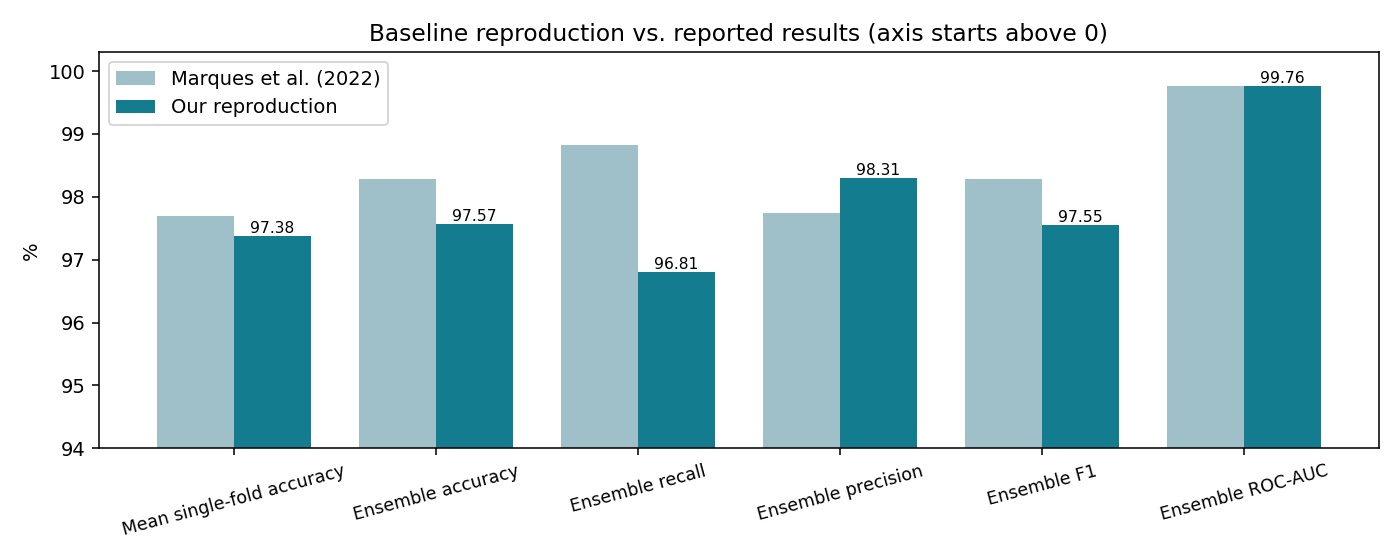

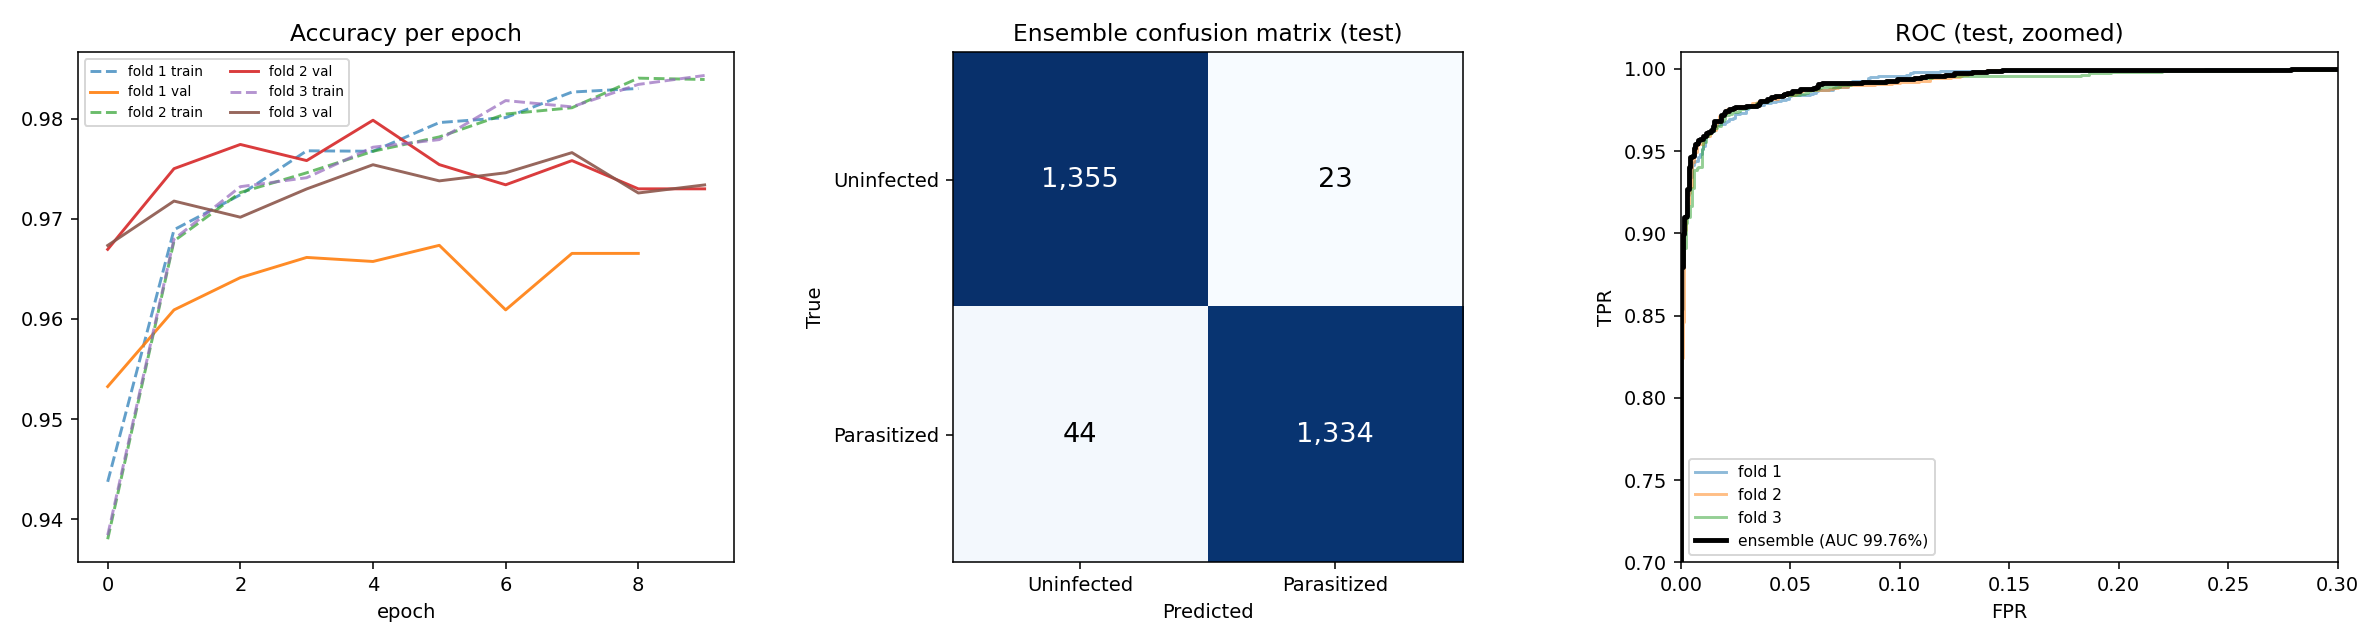

In [5]:
display(Image(f"{R}/A0_vs_paper.png"))
display(Image(f"{R}/A0_curves_cm_roc.png"))

## 4 · The data and the H2 preprocessing

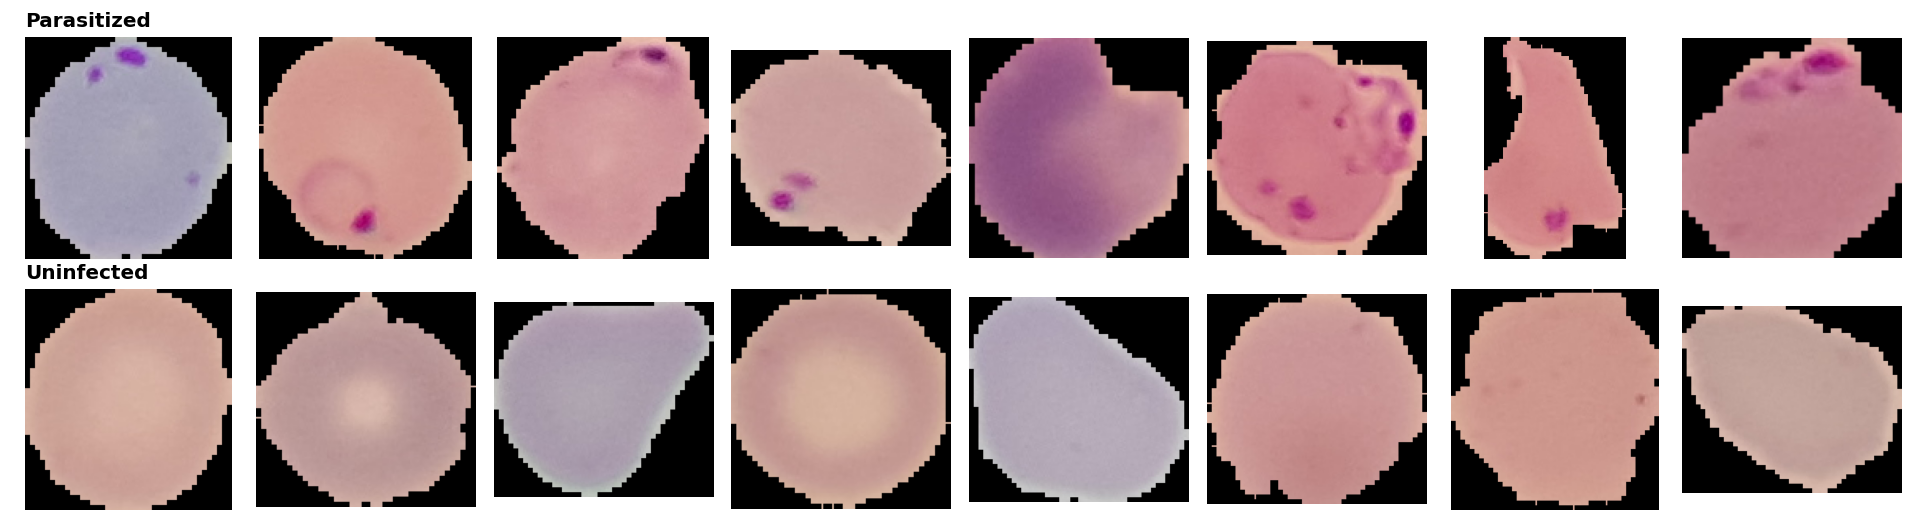

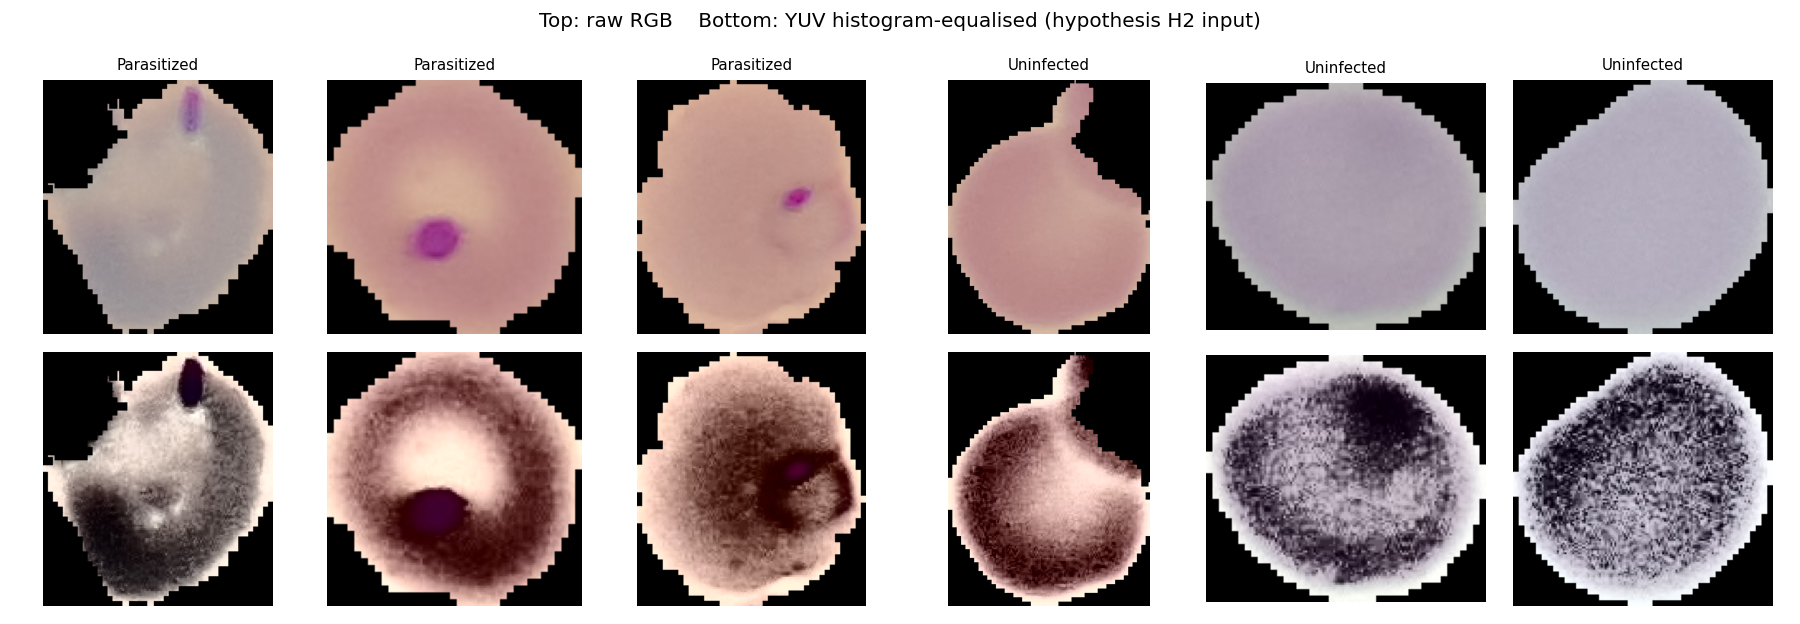

In [6]:
display(Image(f"{R}/samples.png"))
display(Image(f"{R}/yuv_preview.png"))

## 5 · Conclusion

* Mean single-fold accuracy **97.38 ± 0.74 %** (paper 97.70 %), ensemble accuracy **97.57 %** (paper 98.29 %). Both are within 1 pp, so the reproduction succeeds and A0 is our baseline.
* Recall is 2 pp lower than the paper's (96.81 % vs 98.82 %): the ensemble missed 44 infected cells and wrongly flagged 23 healthy ones out of 2,756.
* Next (Milestone 3): our hypotheses H1 (slide-level leakage) and H2 (YUV stain normalisation), tested by experiments A1–A3.